In [1]:
import sys
import os

# Replace with your actual path
#cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
#sys.path.append(cc_grn_functions_path)

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import math
import numpy as np
import pandas as pd
import anndata as ad
from scipy.stats import nbinom
import scanpy as sc
from typing import Tuple
import matplotlib.pyplot as plt


def create_rotation_circuit(angles_list: list[float]) -> QuantumCircuit:
    """
    Initializes a quantum circuit by applying a rotation gate with a
    specified angle to each qubit. The number of qubits is determined
    by the length of the angles_list.

    Args:
        angles_list (list[float]): A list of rotation angles in radians,
                                   one for each qubit.

    Returns:
        QuantumCircuit: The initialized quantum circuit.
    """
    # The number of qubits is determined by the length of the angles list.
    num_qubits = len(angles_list)
    
    # Create a quantum register with the specified number of qubits.
    qr = QuantumRegister(num_qubits, name='q')
    
    # Create a quantum circuit with the quantum register.
    circuit = QuantumCircuit(qr)

    for i in range(num_qubits):
        circuit.ry(angles_list[i], qr[i])
        
    return circuit

def concatenate_circuits_with_separate_measurements(circ1: QuantumCircuit, circ2: QuantumCircuit) -> QuantumCircuit:
    """
    Concatenates two QuantumCircuit objects onto disjoint sets of qubits
    within a larger circuit and adds separate classical registers for measurement
    of each original circuit's qubits.

    Args:
        circ1 (QuantumCircuit): The first quantum circuit.
        circ2 (QuantumCircuit): The second quantum circuit.

    Returns:
        QuantumCircuit: A new circuit combining circ1 and circ2 on separate
                        qubits, with two distinct classical registers for measurements.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    num_total_qubits = ng_circ1 + ng_circ2

    qr_all = QuantumRegister(num_total_qubits, name='q')
    cr_measure1 = ClassicalRegister(ng_circ1, name='c_measure1')
    cr_measure2 = ClassicalRegister(ng_circ2, name='c_measure2')

    circ_all = QuantumCircuit(qr_all, cr_measure1, cr_measure2)

    # Compose circ1 onto the first set of qubits
    circ_all.compose(circ1, qubits=range(ng_circ1), inplace=True)

    # Compose circ2 onto the next set of qubits
    circ_all.compose(circ2, qubits=range(ng_circ1, num_total_qubits), inplace=True)

    return circ_all



def add_cnots_and_measurements_to_circuit(
    base_circuit: QuantumCircuit,
    circ1_num_qubits: int,
    global_cnot_configurations: list[tuple[int, int]]
) -> QuantumCircuit:
    """
    Applies a specified list of CNOT gates (using global qubit indices)
    and then adds measurements to the circuit.

    Args:
        base_circuit (QuantumCircuit): The circuit already containing the two
                                        chunks composed on disjoint qubits.
                                        This circuit should NOT have measurements yet.
        circ1_num_qubits (int): The number of qubits in the first chunk.
                                This is used to determine the classical register split.
        global_cnot_configurations (list[tuple[int, int]]): A list of tuples, where each tuple
                                                      (global_control_idx, global_target_idx)
                                                      specifies a CNOT gate using global qubit indices.

    Returns:
        QuantumCircuit: A new circuit with the specified CNOTs and measurements added.
    """
    circuit_with_cnots = base_circuit.copy()

    qr_all = circuit_with_cnots.qregs[0]
    cr_measure1 = circuit_with_cnots.cregs[0]
    cr_measure2 = circuit_with_cnots.cregs[1]

    for control_q, target_q in global_cnot_configurations:
        # Add checks to ensure indices are valid within the combined circuit
        if not (0 <= control_q < circuit_with_cnots.num_qubits and
                0 <= target_q < circuit_with_cnots.num_qubits and
                control_q != target_q):
            raise ValueError(f"Invalid CNOT indices: ({control_q}, {target_q}). Qubits must be valid and distinct.")

        circuit_with_cnots.cx(qr_all[control_q], qr_all[target_q])
        #circuit_with_cnots.cy(qr_all[control_q], qr_all[target_q])

    # Add measurements after all CNOTs are applied
    circuit_with_cnots.measure(qr_all[0:circ1_num_qubits], cr_measure1)
    circuit_with_cnots.measure(qr_all[circ1_num_qubits:circuit_with_cnots.num_qubits], cr_measure2)

    return circuit_with_cnots

def add_crx_gates_and_measurements_to_circuit(
    base_circuit: QuantumCircuit,
    circ1_num_qubits: int,
    crx_configurations: list[tuple[int, int]], # List of (control, target) global indices
    angles: list[float] # List of angles corresponding to each CRX
) -> QuantumCircuit:
    """
    Applies a specified list of CRX gates (controlled-RX) with given angles
    and then adds measurements to the circuit.

    Args:
        base_circuit (QuantumCircuit): The circuit already containing the two
                                        chunks composed on disjoint qubits.
                                        This circuit should NOT have measurements yet.
        circ1_num_qubits (int): The number of qubits in the first chunk.
                                This is used to determine the classical register split.
        crx_configurations (list[tuple[int, int]]): A list of (control_q, target_q) global qubit
                                                     indices defining where CRX gates will be placed.
        angles (list[float]): A list of rotation angles for each CRX gate,
                              corresponding to the order in `crx_configurations`.

    Returns:
        QuantumCircuit: A new circuit with the specified CRX gates and measurements added.
    """
    circuit_with_crx = base_circuit.copy()
    qr_all = circuit_with_crx.qregs[0]
    cr_measure1 = circuit_with_crx.cregs[0]
    cr_measure2 = circuit_with_crx.cregs[1]

    if len(crx_configurations) != len(angles):
        raise ValueError("Number of CRX configurations must match the number of angles.")

    for i, (control_q, target_q) in enumerate(crx_configurations):
        # Add checks for valid indices
        if not (0 <= control_q < circuit_with_crx.num_qubits and
                0 <= target_q < circuit_with_crx.num_qubits and
                control_q != target_q):
            raise ValueError(f"Invalid CRX indices: ({control_q}, {target_q}). Qubits must be valid and distinct.")
        
        #circuit_with_crx.append(CRXGate(angles[i]), [qr_all[control_q], qr_all[target_q]])
        circuit_with_crx.crx(angles[i], qr_all[control_q], qr_all[target_q]) 

    # Add measurements after all CRX gates are applied
    circuit_with_crx.measure(qr_all[0:circ1_num_qubits], cr_measure1)
    circuit_with_crx.measure(qr_all[circ1_num_qubits:circuit_with_crx.num_qubits], cr_measure2)

    return circuit_with_crx


# --- Re-using the gene count matrix function for demonstration ---
def create_count_matrix_nbinom(binary_matrix: np.ndarray, mu_vector: np.ndarray, r_vector: np.ndarray):
    """
    Creates a count matrix from a binary matrix using a Negative Binomial distribution
    with gene-specific mean and dispersion parameters.
    """
    num_cells, num_genes = binary_matrix.shape
    
    if len(mu_vector) != num_genes or len(r_vector) != num_genes:
        raise ValueError("The length of mu_vector and r_vector must match the number of genes.")
        
    count_matrix = np.zeros_like(binary_matrix, dtype=np.int32)
    
    for j in range(num_genes):
        on_indices = np.where(binary_matrix[:, j] == 1)[0]
        mu_j = mu_vector[j]
        r_j = r_vector[j]
        p_j = r_j / (mu_j + r_j)
        random_counts = nbinom.rvs(n=r_j, p=p_j, size=len(on_indices))
        count_matrix[on_indices, j] = random_counts
        
    return count_matrix

import numpy as np

def create_binary_matrix(joint_counts: dict):
    """
    Generates a binary matrix from a joint histogram dictionary with 0s and 1s.

    Args:
        joint_counts (dict): A dictionary where keys are bit strings
                             (representing rows) and values are their counts.

    Returns:
        np.ndarray: A reconstructed binary matrix with integer values.
    """
    if not joint_counts:
        return np.array([], dtype=int).reshape(0, 0)
    
    # Get the number of genes (columns) from the length of the first key
    first_key = next(iter(joint_counts.keys()))
    num_genes = len(first_key)
    
    reconstructed_rows = []

    # Iterate through the joint counts
    for bit_string, count in joint_counts.items():
        # Reverse the bit string to align with the original g0, g1, ... order
        reversed_bit_string = bit_string[::-1]
        
        # Convert the reversed bit string to a list of integer values (0 or 1)
        row_values = [int(char) for char in reversed_bit_string]
        
        # Repeat the row 'count' number of times
        for _ in range(count):
            reconstructed_rows.append(row_values)
            
    # Convert the list of lists into a NumPy array with integer dtype
    return np.array(reconstructed_rows, dtype=int)

def plot_measurement_histograms(circuit: QuantumCircuit, nshots: int = 1000, title_prefix: str = "", figure_save_name: str = None, figsize: Tuple[int, int] = (12, 5)
):
    """
    Simulates the given circuit and plots histograms for its classical registers
    (c_measure1 and c_measure2) side-by-side. The plots are displayed interactively
    and can optionally be saved to a file.

    Args:
        circuit (QuantumCircuit): The Qiskit QuantumCircuit to simulate and plot.
                                  It must have classical registers named 'c_measure1' and 'c_measure2'.
        nshots (int): The number of shots for the simulation. Defaults to 1000.
        title_prefix (str): A prefix to add to the overall figure title (e.g., "Final Circuit").
        figure_save_name (str, optional): If provided, the figure will be saved to this filename.
                                          Defaults to None (figure only displayed interactively).
    """
    print(f"\n--- Simulating and Plotting Histograms for: {title_prefix} ---")

    # 1. Simulate the circuit
    backend = AerSimulator()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    qc_comp = pm.run(circuit)

    sampler = Sampler(mode=backend)
    job = sampler.run([qc_comp], shots=nshots)

    # 2. Access results and plot histograms
    try:
        result = job.result()[0]
        
        counts_measure1 = None
        counts_measure2 = None

        # Check if classical registers exist and get counts
        if 'c_measure1' in [creg.name for creg in circuit.cregs]:
            counts_measure1 = result.data.c_measure1.get_counts()
            print(f"Counts for c_measure1: {counts_measure1}")
        else:
            print("Warning: Classical register 'c_measure1' not found in circuit. Skipping histogram for c_measure1.")

        if 'c_measure2' in [creg.name for creg in circuit.cregs]:
            counts_measure2 = result.data.c_measure2.get_counts()
            print(f"Counts for c_measure2: {counts_measure2}")
        else:
            print("Warning: Classical register 'c_measure2' not found in circuit. Skipping histogram for c_measure2.")

        # Create a figure with two subplots
        if counts_measure1 is not None or counts_measure2 is not None:
            fig, axes = plt.subplots(1, 2, figsize=figsize) # 1 row, 2 columns
            fig.suptitle(f"{title_prefix} - Measurement Counts ({nshots} shots)", fontsize=16)

            if counts_measure1 is not None:
                plot_histogram(counts_measure1, ax=axes[0], title="c_measure1")
                axes[0].set_title("c_measure1") # Manually set the title
            else:
                axes[0].set_title("c_measure1 (Not Found)")
                axes[0].text(0.5, 0.5, "No data", horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)

            if counts_measure2 is not None:
                plot_histogram(counts_measure2, ax=axes[1], title="c_measure2")
                axes[1].set_title("c_measure2") # Manually set the title
            else:
                axes[1].set_title("c_measure2 (Not Found)")
                axes[1].text(0.5, 0.5, "No data", horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show() # Display the figure

            if figure_save_name:
                try:
                    fig.savefig(figure_save_name)
                    print(f"Histogram figure saved to {figure_save_name}")
                except Exception as save_e:
                    print(f"Error saving figure to {figure_save_name}: {save_e}")
                finally:
                    plt.close(fig) # Close the figure after showing/saving to free memory
        else:
            print("No classical register data available to plot histograms.")

    except AttributeError as e:
        print(f"Error accessing classical register counts: {e}")
        print("Please ensure your circuit has classical registers named 'c_measure1' and 'c_measure2' and measurements are applied.")
    except Exception as e:
        print(f"An unexpected error occurred during simulation or plotting: {e}")
    
    return counts_measure1, counts_measure2

In [3]:
# Create the circuit using the function
ang_ct1 = [np.pi*0.2, np.pi*0.1, np.pi*0.4, np.pi*0.9, np.pi*0.8]
#ang_ct1 = [np.pi*0.2, np.pi*0.0, np.pi*0.0, np.pi*0.9, np.pi*0.0]
circuit_ct1 = create_rotation_circuit(ang_ct1)
# Fn1 the last

# Create the circuit using the function
ang_ct2 = [np.pi*0.2, np.pi*0.3, np.pi*0.2, np.pi*0.7, np.pi*0.5]
#ang_ct2 = [np.pi*0.2, np.pi*0.0, np.pi*0.2, np.pi*0.0, np.pi*0.0]
circuit_ct2 = create_rotation_circuit(ang_ct2)
# the last 2 are Cd44 and Sdc4

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


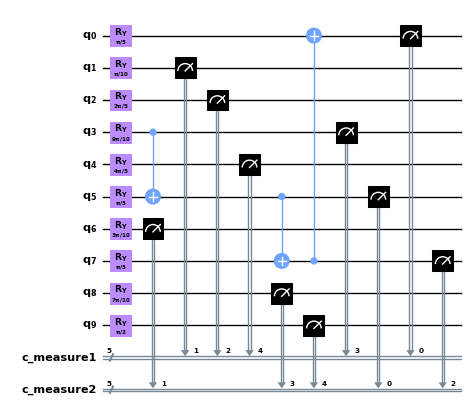

In [4]:
circuit_xct = concatenate_circuits_with_separate_measurements(circuit_ct1, circuit_ct2)
#interaction_map = list([(0,1), (2,1), (3,2), 
#                        (3,5), (5,7), (7,0)])
interaction_map = list([(3,5), (5,7), (7,0)])
#interaction_map = list([(3,5), (7,0)])

circuit_xct_cnot = add_cnots_and_measurements_to_circuit(circuit_xct, circuit_ct1.num_qubits, interaction_map )
circuit_xct_cnot.draw(output="mpl", style="clifford", fold=40,  scale = 0.5)


--- Simulating and Plotting Histograms for: Sampling QC ---
Counts for c_measure1: {'11001': 864, '11000': 272, '01001': 90, '11101': 452, '11100': 123, '01000': 21, '01101': 50, '11111': 15, '10000': 28, '11011': 17, '10001': 7, '10100': 11, '11110': 5, '01100': 18, '11010': 9, '01011': 5, '01111': 1, '00000': 5, '01010': 2, '00101': 1, '10101': 1, '00001': 1, '10010': 1, '00100': 1}
Counts for c_measure2: {'01101': 505, '11000': 79, '10101': 128, '00101': 120, '11101': 513, '01111': 128, '01011': 7, '00111': 29, '01000': 67, '01100': 7, '11001': 43, '00001': 11, '10000': 13, '11111': 128, '01001': 64, '10111': 56, '11011': 7, '00000': 17, '11010': 16, '01010': 19, '10001': 13, '11100': 6, '00010': 6, '00011': 6, '10010': 5, '00100': 3, '11110': 1, '10011': 2, '01110': 1}


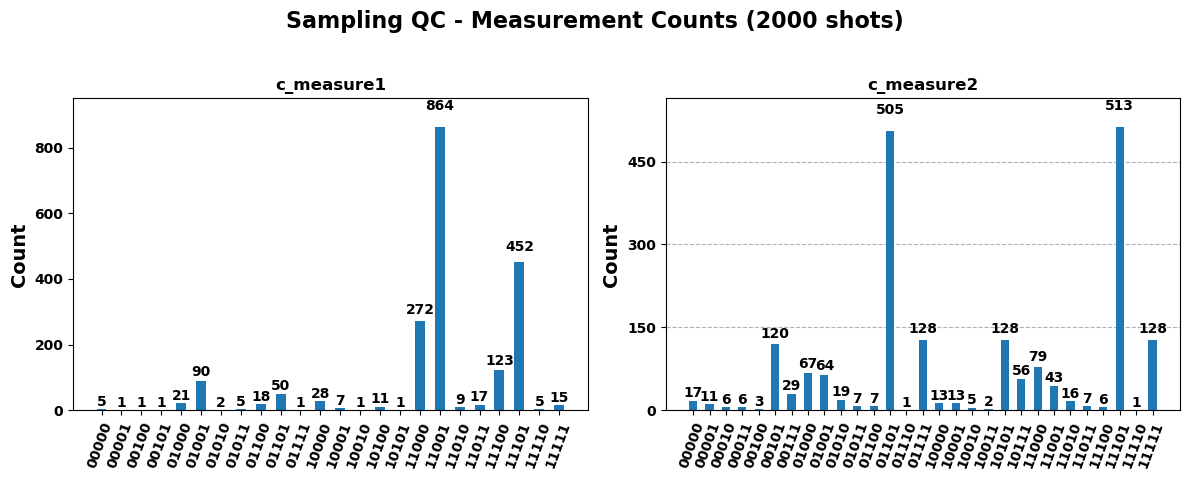

In [5]:
#counts_measure1, counts_measure2 = plot_measurement_histograms(circuit_xct_cnot, nshots=2000, title_prefix="Sampling QC", figure_save_name='measure_counts_sample.svg', figsize=(10,5))
counts_measure1, counts_measure2 = plot_measurement_histograms(circuit_xct_cnot, nshots=2000, title_prefix="Sampling QC")

In [6]:
# Reconstruct the matrix
reconstructed_matrix = create_binary_matrix(counts_measure1)
print("Reconstructed Binary Matrix 1:")
print(reconstructed_matrix)
print("\nShape of the reconstructed matrix 1:", reconstructed_matrix.shape)

Reconstructed Binary Matrix 1:
[[1 0 0 1 1]
 [1 0 0 1 1]
 [1 0 0 1 1]
 ...
 [1 0 0 0 0]
 [0 1 0 0 1]
 [0 0 1 0 0]]

Shape of the reconstructed matrix 1: (2000, 5)


In [7]:
# Reconstruct the matrix
reconstructed_matrix2 = create_binary_matrix(counts_measure2)
print("Reconstructed Binary Matrix 1:")
print(reconstructed_matrix2)
print("\nShape of the reconstructed matrix 2:", reconstructed_matrix2.shape)

Reconstructed Binary Matrix 1:
[[1 0 1 1 0]
 [1 0 1 1 0]
 [1 0 1 1 0]
 ...
 [1 1 0 0 1]
 [1 1 0 0 1]
 [0 1 1 1 0]]

Shape of the reconstructed matrix 2: (2000, 5)


In [8]:
# Genes generated with stringdb:    https://string-db.org/cgi/network?taskId=bJEFw413SU2h&sessionId=bcTc0aENh3tL
# --- Step 1: Create the first AnnData object (representing one cell type) ---
print("Creating the first AnnData object (adata1)...")
 
# LR pairs
#    g3-g5
#    g7-g0
# Internal regulation of CT2 is g5-g7

# Simulating the first dataset's parameters
num_cells1 = 2000
#gene_names1 = ['TGFBR2', 'FLT4', 'KDR', 'PDGFB', 'FN1']
gene_names1 = ['g0', 'g1', 'g2', 'g3', 'g4']

# Set these genes to be highly expressed in this population
#mu_vector1 = np.array([4, 5, 2.5, 1, 3])
#r_vector1 = np.array([0.5, 0.4, 0.6, 0.7, 0.4])
mu_vector1 = np.array([5, 5, 5, 5, 5])
r_vector1 = np.array([1, 1, 1, 1, 1])

# Create dummy data for adata1
np.random.seed(100)
#binary_matrix1 = np.random.randint(0, 2, size=(num_cells1, len(gene_names1)))
count_matrix1 = create_count_matrix_nbinom(reconstructed_matrix, mu_vector1, r_vector1)

cell_ids1 = [f'cell_{i}_ds1_Co' for i in range(num_cells1)]
obs1 = pd.DataFrame(index=cell_ids1)
var1 = pd.DataFrame(index=gene_names1)

# Create the AnnData object for the first dataset
adata1 = ad.AnnData(X=count_matrix1, obs=obs1, var=var1)
print(f"adata1 shape: {adata1.shape}")
print(f"adata1 genes: {adata1.var_names.tolist()}")


Creating the first AnnData object (adata1)...
adata1 shape: (2000, 5)
adata1 genes: ['g0', 'g1', 'g2', 'g3', 'g4']


In [10]:
# --- Step 2: Create the second AnnData object (representing another cell type) ---
print("\nCreating the second AnnData object (adata_mo_mo_mo_mo2)...")

num_cells2 = 2000
#gene_names2 = ['PDGFRB', 'NRP1', 'TGFB1', 'CD44', 'SDC4']
gene_names2 = ['g5', 'g6', 'g7', 'g8', 'g9']

# Set these genes to be highly expressed in this population
#mu_vector2 = np.array([2.5, 4.5, 3.5, 1, 2])
#r_vector2 = np.array([0.8, 0.6, 0.9, 0.7, 0.8])
mu_vector2 = np.array([5, 5, 5, 5, 5])
r_vector2 = np.array([1, 1, 1, 1, 1])

# Create dummy data for adata2
np.random.seed(200)
#binary_matrix2 = np.random.randint(0, 2, size=(num_cells2, len(gene_names2)))
count_matrix2 = create_count_matrix_nbinom(reconstructed_matrix2, mu_vector2, r_vector2)
cell_ids2 = [f'cell_{i}_ds2_Co' for i in range(num_cells2)]
obs2 = pd.DataFrame(index=cell_ids2)
var2 = pd.DataFrame(index=gene_names2)

# Create the AnnData object for the second dataset
adata2 = ad.AnnData(X=count_matrix2, obs=obs2, var=var2)
print(f"adata2 shape: {adata2.shape}")
print(f"adata2 genes: {adata2.var_names.tolist()}")


Creating the second AnnData object (adata_mo_mo_mo_mo2)...
adata2 shape: (2000, 5)
adata2 genes: ['g5', 'g6', 'g7', 'g8', 'g9']


In [11]:
# --- Step 3: Add housekeeping genes ---
print("\nAdding 10 random housekeeping genes to both datasets...")

num_housekeeping_genes = 50
housekeeping_gene_names = [f'HKG_{i}' for i in range(num_housekeeping_genes)]

# Housekeeping genes are highly and consistently expressed across all cells
mu_hkg = np.full(num_housekeeping_genes, 100.0)
r_hkg = np.full(num_housekeeping_genes, 5.0) # High r for low dispersion

# Create a binary matrix with 1s for all housekeeping genes across all cells
binary_matrix_hkg = np.ones((num_cells1 + num_cells2, num_housekeeping_genes), dtype=int)
count_matrix_hkg = create_count_matrix_nbinom(binary_matrix_hkg, mu_hkg, r_hkg)

# Create an AnnData object for the housekeeping genes
hkg_adata = ad.AnnData(
    X=count_matrix_hkg,
    obs=pd.DataFrame(index=list(adata1.obs_names) + list(adata2.obs_names)),
    var=pd.DataFrame(index=housekeeping_gene_names)
)

# --- Step 4: Merge the datasets ---
print("\nMerging all three AnnData objects...")

# First, merge adata1 and adata2 by cells
merged_cell_adata = ad.concat(
    [adata1, adata2],
    axis=0,
    join='outer',
    label='BatchID',
    keys=['ds1_Co', 'ds2_Co']
)

# Fill any NaN values with 0
merged_cell_adata.X[np.isnan(merged_cell_adata.X)] = 0

# Then, merge the combined dataset with the housekeeping genes by features
adata_co = ad.concat(
    [merged_cell_adata, hkg_adata],
    axis=1,
    join='inner',
    merge='unique'
)

print("\nFinal Merged AnnData object created:")
print(adata_co)
print(f"Merged shape: {adata_co.shape}")
print(f"Merged genes: {adata_co.var_names.tolist()}")


Adding 10 random housekeeping genes to both datasets...

Merging all three AnnData objects...

Final Merged AnnData object created:
AnnData object with n_obs × n_vars = 4000 × 60
    obs: 'BatchID'
Merged shape: (4000, 60)
Merged genes: ['g0', 'g1', 'g2', 'g3', 'g4', 'g5', 'g6', 'g7', 'g8', 'g9', 'HKG_0', 'HKG_1', 'HKG_2', 'HKG_3', 'HKG_4', 'HKG_5', 'HKG_6', 'HKG_7', 'HKG_8', 'HKG_9', 'HKG_10', 'HKG_11', 'HKG_12', 'HKG_13', 'HKG_14', 'HKG_15', 'HKG_16', 'HKG_17', 'HKG_18', 'HKG_19', 'HKG_20', 'HKG_21', 'HKG_22', 'HKG_23', 'HKG_24', 'HKG_25', 'HKG_26', 'HKG_27', 'HKG_28', 'HKG_29', 'HKG_30', 'HKG_31', 'HKG_32', 'HKG_33', 'HKG_34', 'HKG_35', 'HKG_36', 'HKG_37', 'HKG_38', 'HKG_39', 'HKG_40', 'HKG_41', 'HKG_42', 'HKG_43', 'HKG_44', 'HKG_45', 'HKG_46', 'HKG_47', 'HKG_48', 'HKG_49']


In [12]:
# --- Step 6: Processing the data with Scanpy ---
print("\nStarting data processing with Scanpy...")

# Load the merged AnnData object
adata = adata_co.copy()

# The 'batch' column is already in obs from the `ad.concat` step.
print("\nDataset batches are now stored in adata.obs['BatchID']:")
print(adata.obs['BatchID'].value_counts())

# --- 6.1 Quality Control (QC) and Metrics ---
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)

# --- 6.2 Normalization and Log-Transformation ---
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# --- 6.3 Scaling the Data ---
sc.pp.scale(adata, max_value=10)

# --- 6.4 Principal Component Analysis (PCA) ---
# Check if the number of genes is sufficient for PCA
if adata.n_vars > 0:
    sc.tl.pca(adata, svd_solver='arpack')
else:
    print("\nNo genes remaining after filtering. Skipping PCA.")

# --- 6.5 UMAP (Uniform Manifold Approximation and Projection) ---
# Set n_pcs to be the minimum of 20 and the number of genes
n_pcs = min(10, adata.n_vars)
if adata.n_vars > 1:
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=n_pcs)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, flavor="leidenalg", n_iterations=2)

else:
    print("\nNot enough genes to compute neighbors and UMAP. Skipping.")

# --- 6.7 Final Output ---
print("\nFinal AnnData object after UMAP has been computed:")
print(adata)
print("\nUMAP coordinates are stored in adata.obsm['X_umap'].")
print("PCA coordinates are stored in adata.obsm['X_pca'].")



Starting data processing with Scanpy...

Dataset batches are now stored in adata.obs['BatchID']:
BatchID
ds1_Co    2000
ds2_Co    2000
Name: count, dtype: int64

Final AnnData object after UMAP has been computed:
AnnData object with n_obs × n_vars = 4000 × 60
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

UMAP coordinates are stored in adata.obsm['X_umap'].
PCA coordinates are stored in adata.obsm['X_pca'].


C:\Users\ssromerogon\AppData\Local\Temp\ipykernel_43792\4153235940.py:34: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, flavor="leidenalg", n_iterations=2)


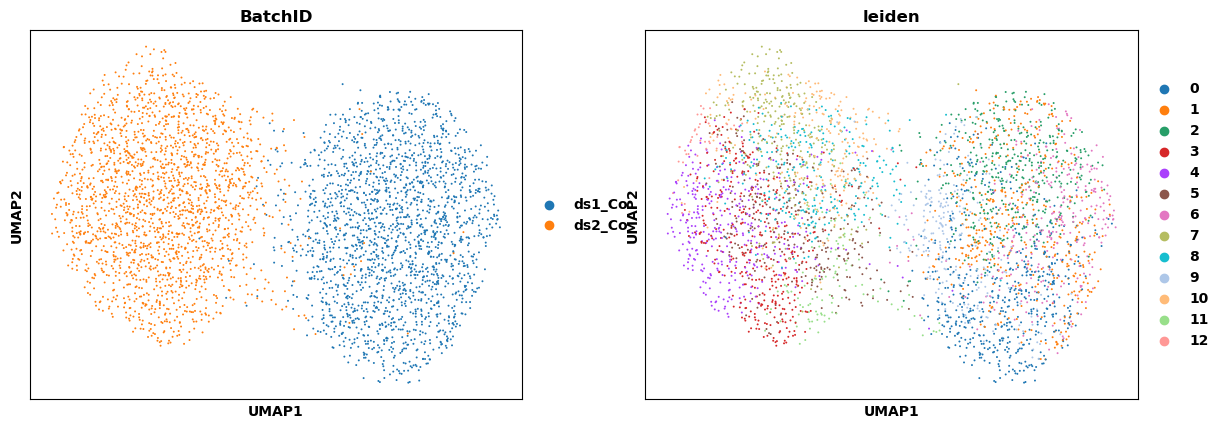

In [13]:
sc.pl.umap(
    adata,
    color=["BatchID", "leiden"],
    # Setting a smaller point size to get prevent overlap
    size=8,
)

In [19]:
import pandas as pd
import numpy as np
import scanpy as sc

# Check if adata.X is a sparse matrix, convert to dense if necessary
# This makes your code robust to different data formats
if isinstance(adata.X, np.ndarray):
    gene_expression_matrix = adata.X.T
else: # assuming it's a sparse matrix
    gene_expression_matrix = adata.X.T.toarray()

# Create the DataFrame
gene_expression_df = pd.DataFrame(
    gene_expression_matrix,
    index=adata.var_names,
    columns=adata.obs_names
)

# Calculate the correlation matrix.
corr_matrix = gene_expression_df.T.corr(method='pearson')

# Filter for strong correlations to simplify the network.
# A common threshold is an absolute correlation of 0.5 or higher.
threshold = 0.2
adj_matrix = np.where(np.abs(corr_matrix) > threshold, corr_matrix, 0)
np.fill_diagonal(adj_matrix, 0)

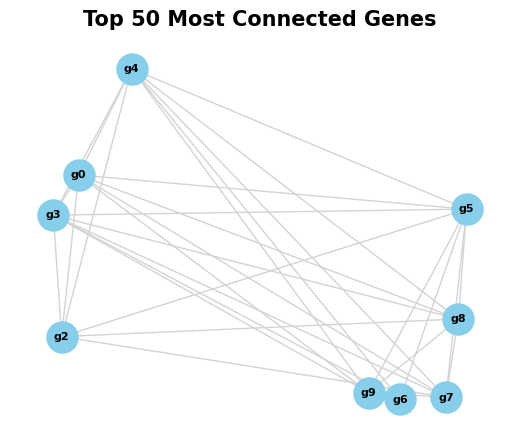

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph object from the adjacency matrix
G = nx.from_numpy_array(adj_matrix)

# Map the integer indices back to gene names
gene_names = adata.var_names
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)

# Remove nodes that have no connections (isolated genes)
G.remove_nodes_from(list(nx.isolates(G)))

# To get a cleaner plot of a sub-network, you can find the most highly connected genes
degrees = dict(G.degree())
most_connected_genes = sorted(degrees, key=degrees.get, reverse=True)[:50]
subgraph = G.subgraph(most_connected_genes)

# Set a new layout specifically for the subgraph
subgraph_pos = nx.fruchterman_reingold_layout(subgraph)

plt.figure(figsize=(5, 4))
nx.draw(subgraph,
        pos=subgraph_pos,  # Use the new layout here
        with_labels=True,
        node_size=500,
        font_size=8,
        node_color='skyblue',
        edge_color='lightgray')
plt.title("Top 50 Most Connected Genes", fontsize=15)
plt.show()

In [21]:
# Saving mono cultured simulation
# Create the circuit using the function
# ang_4g = [np.pi*0.2, np.pi*0.5, np.pi*0.4, np.pi*0.3, np.pi*0.7]
# circuit_ct1 = create_rotation_circuit(ang_4g)

# # Create the circuit using the function
# ang_ct2 = [np.pi*0.4, np.pi*0.4, np.pi*0.3, np.pi*0.6, np.pi*0.6]
# circuit_ct2 = create_rotation_circuit(ang_ct2)

# Create the circuit using the function
ang_ct1 = [np.pi*0.2, np.pi*0.1, np.pi*0.4, np.pi*0.9, np.pi*0.8]
circuit_ct1 = create_rotation_circuit(ang_ct1)
# Fn1 the last

# Create the circuit using the function
ang_ct2 = [np.pi*0.2, np.pi*0.3, np.pi*0.2, np.pi*0.7, np.pi*0.5]
circuit_ct2 = create_rotation_circuit(ang_ct2)
# the last 2 are Cd44 and Sdc4

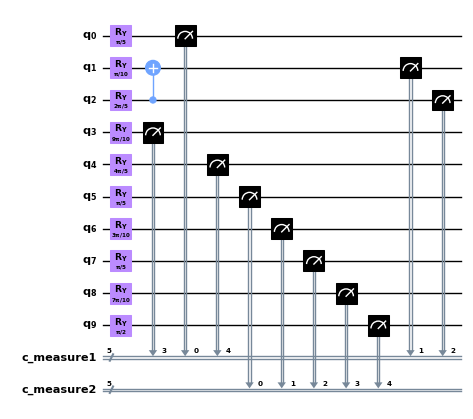

In [22]:
circuit_xct = concatenate_circuits_with_separate_measurements(circuit_ct1, circuit_ct2)
#interaction_map = list([(0,1), (2,1), (2,3), 
#                        (6,5), (5, 7)])
interaction_map = list([(2,1)])

#interaction_map = list([(1, 0)])

circuit_xct_cnot = add_cnots_and_measurements_to_circuit(circuit_xct, circuit_ct1.num_qubits, interaction_map )
circuit_xct_cnot.draw(output="mpl", style="clifford", fold=40,  scale = 0.5)


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'11000': 1029, '11111': 77, '11110': 520, '01110': 50, '01000': 110, '11010': 24, '11001': 109, '01010': 2, '11100': 8, '10010': 1, '01001': 15, '10000': 20, '10110': 17, '01111': 7, '00000': 1, '00001': 1, '01100': 1, '11011': 3, '11101': 1, '10111': 2, '10001': 1, '00110': 1}
Counts for c_measure2: {'11000': 505, '10000': 129, '01000': 512, '01011': 19, '00100': 10, '00000': 138, '11010': 110, '10110': 4, '01100': 54, '00010': 40, '00001': 15, '01010': 147, '11001': 55, '10011': 3, '00011': 8, '10010': 29, '11100': 62, '11110': 19, '01001': 57, '10001': 9, '11101': 9, '10100': 8, '00111': 1, '01110': 19, '11011': 17, '10101': 2, '00110': 3, '01101': 10, '11111': 2, '00101': 2, '10111': 1, '01111': 1}


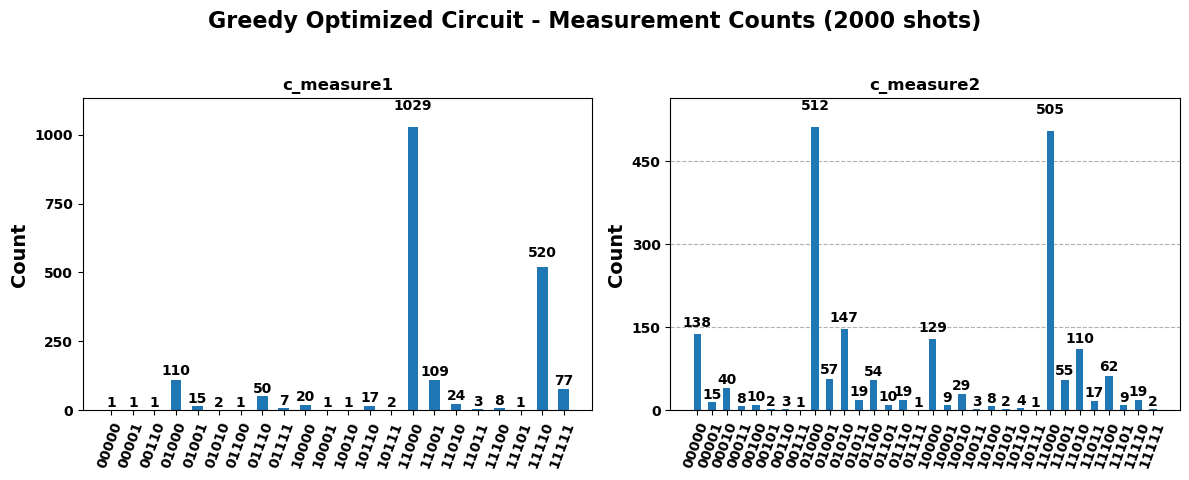

In [23]:
counts_measure1, counts_measure2 = plot_measurement_histograms(circuit_xct_cnot, nshots=2000, title_prefix="Greedy Optimized Circuit")

In [24]:
# Reconstruct the matrix
reconstructed_matrix = create_binary_matrix(counts_measure1)
print("Reconstructed Binary Matrix 1:")
print(reconstructed_matrix)
print("\nShape of the reconstructed matrix 1:", reconstructed_matrix.shape)
# Reconstruct the matrix
reconstructed_matrix2 = create_binary_matrix(counts_measure2)
print("Reconstructed Binary Matrix 1:")
print(reconstructed_matrix2)
print("\nShape of the reconstructed matrix 1:", reconstructed_matrix2.shape)

Reconstructed Binary Matrix 1:
[[0 0 0 1 1]
 [0 0 0 1 1]
 [0 0 0 1 1]
 ...
 [1 1 1 0 1]
 [1 0 0 0 1]
 [0 1 1 0 0]]

Shape of the reconstructed matrix 1: (2000, 5)
Reconstructed Binary Matrix 1:
[[0 0 0 1 1]
 [0 0 0 1 1]
 [0 0 0 1 1]
 ...
 [1 0 1 0 0]
 [1 1 1 0 1]
 [1 1 1 1 0]]

Shape of the reconstructed matrix 1: (2000, 5)


In [25]:
# Genes generated with stringdb:    https://string-db.org/cgi/network?taskId=bJEFw413SU2h&sessionId=bcTc0aENh3tL
# --- Step 1: Create the first AnnData object (representing one cell type) ---
print("Creating the first AnnData object (adata1)...")

# Simulating the first dataset's parameters
num_cells1 = 2000
#gene_names1 = ['TGFBR2', 'FLT4', 'KDR', 'PDGFB', 'FN1']
gene_names1 = ['g0', 'g1', 'g2', 'g3', 'g4']

# Set these genes to be highly expressed in this population
# mu_vector1 = np.array([0.8, 8, 6, 1, 3])
# r_vector1 = np.array([0.6, 0.9, 0.6, 0.4, 0.7])
mu_vector1 = np.array([5, 5, 5, 5, 5])
r_vector1 = np.array([1, 1, 1, 1, 1])

# Create dummy data for adata1
np.random.seed(100)
#binary_matrix1 = np.random.randint(0, 2, size=(num_cells1, len(gene_names1)))
count_matrix1 = create_count_matrix_nbinom(reconstructed_matrix, mu_vector1, r_vector1)

cell_ids1 = [f'cell_{i}_ds1_Mo' for i in range(num_cells1)]
obs1 = pd.DataFrame(index=cell_ids1)
var1 = pd.DataFrame(index=gene_names1)

# Create the AnnData object for the first dataset
adata1 = ad.AnnData(X=count_matrix1, obs=obs1, var=var1)
print(f"adata1 shape: {adata1.shape}")
print(f"adata1 genes: {adata1.var_names.tolist()}")

Creating the first AnnData object (adata1)...
adata1 shape: (2000, 5)
adata1 genes: ['g0', 'g1', 'g2', 'g3', 'g4']


In [ ]:
# --- Step 2: Create the second AnnData object (representing another cell type) ---
print("\nCreating the second AnnData object (adata2)...")

num_cells2 = 2000
gene_names2 = ['g5', 'g6', 'g7', 'g8', 'g9']

# Set these genes to be highly expressed in this population
# mu_vector2 = np.array([0.5, 3, 1.5, 1.1, 2])
# r_vector2 = np.array([0.4, 0.8, 0.5, 0.7, 0.7])
mu_vector2 = np.array([5, 5, 5, 5, 5])
r_vector2 = np.array([1, 1, 1, 1, 1])

# Create dummy data for adata2
np.random.seed(200)
#binary_matrix2 = np.random.randint(0, 2, size=(num_cells2, len(gene_names2)))
count_matrix2 = create_count_matrix_nbinom(reconstructed_matrix2, mu_vector2, r_vector2)
cell_ids2 = [f'cell_{i}_ds2_Mo' for i in range(num_cells2)]
obs2 = pd.DataFrame(index=cell_ids2)
var2 = pd.DataFrame(index=gene_names2)

# Create the AnnData object for the second dataset
adata2 = ad.AnnData(X=count_matrix2, obs=obs2, var=var2)
print(f"adata2 shape: {adata2.shape}")
print(f"adata2 genes: {adata2.var_names.tolist()}")



Creating the second AnnData object (adata2)...
adata2 shape: (2000, 5)
adata2 genes: ['PDGFRB', 'NRP1', 'TGFB1', 'CD44', 'SDC4']


In [ ]:
# --- Step 3: Add housekeeping genes ---
print("\nAdding 10 random housekeeping genes to both datasets...")

num_housekeeping_genes = 50
housekeeping_gene_names = [f'HKG_{i}' for i in range(num_housekeeping_genes)]

# Housekeeping genes are highly and consistently expressed across all cells
mu_hkg = np.full(num_housekeeping_genes, 80.0)
r_hkg = np.full(num_housekeeping_genes, 6.0) # High r for low dispersion

# Create a binary matrix with 1s for all housekeeping genes across all cells
binary_matrix_hkg = np.ones((num_cells1 + num_cells2, num_housekeeping_genes), dtype=int)
count_matrix_hkg = create_count_matrix_nbinom(binary_matrix_hkg, mu_hkg, r_hkg)

# Create an AnnData object for the housekeeping genes
hkg_adata = ad.AnnData(
    X=count_matrix_hkg,
    obs=pd.DataFrame(index=list(adata1.obs_names) + list(adata2.obs_names)),
    var=pd.DataFrame(index=housekeeping_gene_names)
)

# --- Step 4: Merge the datasets ---
print("\nMerging all three AnnData objects...")

# First, merge adata1 and adata2 by cells
merged_cell_adata = ad.concat(
    [adata1, adata2],
    axis=0,
    join='outer',
    label='BatchID',
    keys=['ds1_Mo', 'ds2_Mo']
)

# Fill any NaN values with 0
merged_cell_adata.X[np.isnan(merged_cell_adata.X)] = 0

# Then, merge the combined dataset with the housekeeping genes by features
adata_mo = ad.concat(
    [merged_cell_adata, hkg_adata],
    axis=1,
    join='inner',
    merge='unique'
)

print("\nFinal Merged AnnData object created:")
print(adata_mo)
print(f"Merged shape: {adata_mo.shape}")
print(f"Merged genes: {adata_mo.var_names.tolist()}")



Adding 10 random housekeeping genes to both datasets...

Merging all three AnnData objects...

Final Merged AnnData object created:
AnnData object with n_obs × n_vars = 4000 × 60
    obs: 'BatchID'
Merged shape: (4000, 60)
Merged genes: ['CD44', 'FLT4', 'FN1', 'KDR', 'NRP1', 'PDGFB', 'PDGFRB', 'SDC4', 'TGFB1', 'TGFBR2', 'HKG_0', 'HKG_1', 'HKG_2', 'HKG_3', 'HKG_4', 'HKG_5', 'HKG_6', 'HKG_7', 'HKG_8', 'HKG_9', 'HKG_10', 'HKG_11', 'HKG_12', 'HKG_13', 'HKG_14', 'HKG_15', 'HKG_16', 'HKG_17', 'HKG_18', 'HKG_19', 'HKG_20', 'HKG_21', 'HKG_22', 'HKG_23', 'HKG_24', 'HKG_25', 'HKG_26', 'HKG_27', 'HKG_28', 'HKG_29', 'HKG_30', 'HKG_31', 'HKG_32', 'HKG_33', 'HKG_34', 'HKG_35', 'HKG_36', 'HKG_37', 'HKG_38', 'HKG_39', 'HKG_40', 'HKG_41', 'HKG_42', 'HKG_43', 'HKG_44', 'HKG_45', 'HKG_46', 'HKG_47', 'HKG_48', 'HKG_49']


In [ ]:
# --- Step 6: Processing the data with Scanpy ---
print("\nStarting data processing with Scanpy...")

# Load the merged AnnData object
adata = adata_mo.copy()

# The 'batch' column is already in obs from the `ad.concat` step.
print("\nDataset batches are now stored in adata.obs['batch']:")
print(adata.obs['BatchID'].value_counts())

# --- 6.1 Quality Control (QC) and Metrics ---
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)

# --- 6.2 Normalization and Log-Transformation ---
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# --- 6.3 Scaling the Data ---
sc.pp.scale(adata, max_value=10)

# --- 6.4 Principal Component Analysis (PCA) ---
# Check if the number of genes is sufficient for PCA
if adata.n_vars > 0:
    sc.tl.pca(adata, svd_solver='arpack')
else:
    print("\nNo genes remaining after filtering. Skipping PCA.")

# --- 6.5 UMAP (Uniform Manifold Approximation and Projection) ---
# Set n_pcs to be the minimum of 20 and the number of genes
n_pcs = min(10, adata.n_vars)
if adata.n_vars > 1:
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=n_pcs)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, flavor="leidenalg", n_iterations=2)

else:
    print("\nNot enough genes to compute neighbors and UMAP. Skipping.")

# --- 6.7 Final Output ---
print("\nFinal AnnData object after UMAP has been computed:")
print(adata)
print("\nUMAP coordinates are stored in adata.obsm['X_umap'].")
print("PCA coordinates are stored in adata.obsm['X_pca'].")



Starting data processing with Scanpy...

Dataset batches are now stored in adata.obs['batch']:
BatchID
ds1_Mo    2000
ds2_Mo    2000
Name: count, dtype: int64

Final AnnData object after UMAP has been computed:
AnnData object with n_obs × n_vars = 4000 × 60
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

UMAP coordinates are stored in adata.obsm['X_umap'].
PCA coordinates are stored in adata.obsm['X_pca'].


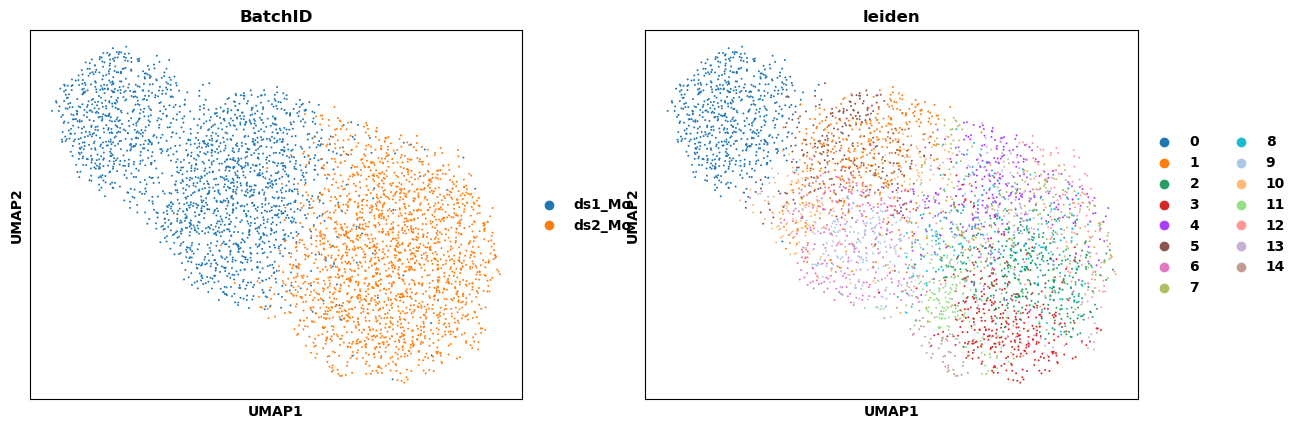

In [ ]:
sc.pl.umap(
    adata,
    color=["BatchID", "leiden"],
    # Setting a smaller point size to get prevent overlap
    size=8,
)

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc 

#adata_mo = adata2 #sc.read_h5ad("merged_datasets_mo.h5ad")

adata_mo.obs['CellType'] = None
adata_mo.obs['Batch2'] = 'Mo'

# Assign 'CAF' where the 'batch' is 'ds1'.
adata_mo.obs.loc[adata_mo.obs['BatchID'] == 'ds1_Mo', 'CellType'] = 'CAF'

# Assign 'Fibroblasts' where the 'batch' is 'ds2'.
adata_mo.obs.loc[adata_mo.obs['BatchID'] == 'ds2_Mo', 'CellType'] = 'Fibroblasts'
adata_mo.obs['CellType'] = adata_mo.obs['CellType'].astype('category')

print(adata_mo.obs['CellType'].head())

cell_0_ds1_Mo    CAF
cell_1_ds1_Mo    CAF
cell_2_ds1_Mo    CAF
cell_3_ds1_Mo    CAF
cell_4_ds1_Mo    CAF
Name: CellType, dtype: category
Categories (2, object): ['CAF', 'Fibroblasts']


In [ ]:
adata_mo.obs['BatchID']

cell_0_ds1_Mo       ds1_Mo
cell_1_ds1_Mo       ds1_Mo
cell_2_ds1_Mo       ds1_Mo
cell_3_ds1_Mo       ds1_Mo
cell_4_ds1_Mo       ds1_Mo
                     ...  
cell_1995_ds2_Mo    ds2_Mo
cell_1996_ds2_Mo    ds2_Mo
cell_1997_ds2_Mo    ds2_Mo
cell_1998_ds2_Mo    ds2_Mo
cell_1999_ds2_Mo    ds2_Mo
Name: BatchID, Length: 4000, dtype: category
Categories (2, object): ['ds1_Mo', 'ds2_Mo']

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc 

adata_co.obs['CellType'] = None
adata_co.obs['Batch2'] = 'Co'

# Assign 'CAF' where the 'batch' is 'ds1'.
adata_co.obs.loc[adata_co.obs['BatchID'] == 'ds1_Co', 'CellType'] = 'CAF'

# Assign 'Fibroblasts' where the 'batch' is 'ds2'.
adata_co.obs.loc[adata_co.obs['BatchID'] == 'ds2_Co', 'CellType'] = 'Fibroblasts'
adata_co.obs['CellType'] = adata_co.obs['CellType'].astype('category')

print(adata_co.obs['CellType'].head())

cell_0_ds1_Co    CAF
cell_1_ds1_Co    CAF
cell_2_ds1_Co    CAF
cell_3_ds1_Co    CAF
cell_4_ds1_Co    CAF
Name: CellType, dtype: category
Categories (2, object): ['CAF', 'Fibroblasts']


In [ ]:
import anndata as ad

# Assuming adata_mo and adata_co are already loaded
adatas = [adata_mo, adata_co]

adata_merged = ad.concat(
    adatas,
    join='inner',  # Keeps only the variables (genes) that are common to both datasets
    label='condition', # Creates a new column named 'condition' in adata_merged.obs
    keys=['monoculture', 'coculture'] # Populates the 'condition' column with 'monoculture' and 'coculture'
)

In [ ]:
adata_merged

AnnData object with n_obs × n_vars = 8000 × 60
    obs: 'BatchID', 'CellType', 'Batch2', 'condition'

In [ ]:
import scipy.sparse as sp
adata_merged.X = sp.csr_matrix(adata_merged.X)
adata_merged.write_h5ad('merged_datasets_co_mo.h5ad')